**Cell 1**

# 04 Air traffic

OpenSky miles (public Saturday) against EIA demand (public Wednesday), PADD 1 and PADD 5, 2019-01 to 2020-06: 75 weeks, 61 pre-COVID.

1. Nowcast of EIA demand.
2. COVID sequence.
3. Miles against spreads.

In [1]:
# Cell 2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 200)

**Cell 3**

**Goal.** Load the libraries this notebook uses.

**Method.** pandas and numpy for the weekly frame, matplotlib and cycler for the charts, statsmodels for the regressions in Cell 27 and their Newey-West standard errors.

**Outcome.** The libraries load.

**Interpretation.** Every later cell depends on this one.

In [2]:
# Cell 4
# chart style
SURFACE, INK, INK_2, MUTED, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.titlelocation': 'left', 'axes.titlesize': 12,
    'axes.titleweight': 'semibold', 'lines.linewidth': 2, 'legend.frameon': False, 'figure.figsize': (10, 4),
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'Arial', 'DejaVu Sans'],
    'axes.prop_cycle': cycler(color=[BLUE, ORANGE, AQUA, YELLOW]),
})

**Cell 5**

**Goal.** Fix one chart style for every figure in the notebook.

**Method.** The same matplotlib defaults as notebook 03: an off-white ground, four colours, left-aligned titles, and the top and right spines hidden.

**Outcome.** Every later figure takes these settings.

**Interpretation.** Notebooks 03 and 04 save figures into the same folder, so the two carry one style.

In [3]:
# Cell 6
PANEL_FILE = '../data/weekly_panel.csv'
SCORE_FILE = '../results/price_eda_scorecard.csv'
BEFORE = ('2019-03-01', '2020-02-28')     # pre-COVID scoring window
COVID = ('2020-03-06', '2020-05-29')
SCALE_WEEKS = 8
FDR_Q = 0.10
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)

**Cell 7**

**Goal.** Fix the two scoring windows, the scaling window and the false discovery level.

**Method.** Scoring before the collapse runs 2019-03-01 to 2020-02-28, and the collapse window runs 2020-03-06 to 2020-05-29. The scaling window is 8 weeks. The false discovery rate is 0.10.

**Outcome.** Four settings, and the `figures` and `results` folders created.

**Interpretation.** The first window opens in March 2019 because the 8-week scaling consumes eight weeks of a miles series starting 2019-01-04. The two windows stay apart so the collapse weeks read as a separate test in place of 13 weeks inside one average.

In [4]:
# Cell 8
PANEL = pd.read_csv(PANEL_FILE, index_col=0, parse_dates=True)
A = PANEL.loc['2019-01-04':'2020-06-05'].copy()
A['BOTH_MILES'] = A['P1_MILES'] + A['P5_MILES']      # PADD 1 + PADD 5
A[['P1_MILES', 'P5_MILES', 'P5_JET_DEMAND', 'US_JET_DEMAND']].describe().round(0)

,P1_MILES,P5_MILES,P5_JET_DEMAND,US_JET_DEMAND
count,75.0,75.0,74.0,74.0
mean,5530651.0,5031966.0,499.0,1598.0
std,1558797.0,1184230.0,130.0,414.0
min,1453169.0,1909530.0,100.0,353.0
25%,5062778.0,4770195.0,454.0,1523.0
50%,5873682.0,5448494.0,522.0,1717.0
75%,6812098.0,5803927.0,576.0,1847.0
max,7030558.0,6204109.0,785.0,2088.0


**Cell 9**

**Goal.** Load the panel and build a combined miles series.

**Method.** Keep 2019-01-04 to 2020-06-05, add PADD 1 and PADD 5 miles into `BOTH_MILES`, and describe the four columns.

**Outcome.** 75 weeks. PADD 1 miles mean 5.53 million a day, range 1.45 to 7.03 million. PADD 5 mean 5.03 million, range 1.91 to 6.20 million. PADD 5 jet demand mean 499 thousand barrels a day, range 100 to 785. US demand mean 1,598, range 353 to 2,088.

**Interpretation.** Every minimum belongs to April 2020: miles fell to a fifth of their level and West Coast demand to a fifth of its own. Those weeks dominate any statistic taken across all 75, which is the reason every score below is reported on the two windows apart.

**Cell 10**

## 1. Nowcast

Nowcast(t) = miles(t) × sum of demand(t-8 to t-1) / sum of miles(t-8 to t-1).
Benchmarks: demand(t-1); mean of demand(t-4 to t-1).

In [5]:
# Cell 11
PAIRS = [('P5_MILES', 'P5_JET_DEMAND'), ('P5_MILES', 'P5_JET_DEMAND_4W'), ('BOTH_MILES', 'US_JET_DEMAND'), ('BOTH_MILES', 'US_JET_DEMAND_4W')]
for miles, dem in PAIRS:
    scale = A[dem].shift(1).rolling(SCALE_WEEKS).sum() / A[miles].shift(1).rolling(SCALE_WEEKS).sum()
    A[f'NOWCAST_{dem}'] = scale * A[miles]
    A[f'LAST_{dem}'] = A[dem].shift(1)
    A[f'AVG4_{dem}'] = A[dem].shift(1).rolling(4).mean()
A[['P5_JET_DEMAND', 'NOWCAST_P5_JET_DEMAND', 'LAST_P5_JET_DEMAND', 'AVG4_P5_JET_DEMAND']].loc['2020-03-06':'2020-04-24'].round(0)

,P5_JET_DEMAND,NOWCAST_P5_JET_DEMAND,LAST_P5_JET_DEMAND,AVG4_P5_JET_DEMAND
week_ending,,,,
2020-03-06,453.0,506.0,569.0,480.0
2020-03-13,582.0,513.0,453.0,442.0
2020-03-20,513.0,519.0,582.0,508.0
2020-03-27,511.0,484.0,513.0,530.0
2020-04-03,243.0,412.0,511.0,515.0
2020-04-10,146.0,304.0,243.0,462.0
2020-04-17,241.0,226.0,146.0,353.0
2020-04-24,327.0,187.0,241.0,285.0


**Cell 12**

**Goal.** Turn miles into a demand figure a trader can read on Saturday.

**Method.** Nowcast(t) = miles(t) x the ratio of demand to miles over the previous 8 weeks. That ratio converts miles into barrels and drops the receiver-network drift notebook 02 measured, because a ratio refitted every week absorbs a slow trend in either series. Two benchmarks stand against it: last week's published demand, and the mean of the last four published weeks.

**Outcome.** West Coast weekly demand against its nowcast, March and April 2020: 453 against 506, 582 against 513, 513 against 519, 511 against 484, 243 against 412, 146 against 304, 241 against 226, 327 against 187.

**Interpretation.** Through the collapse the nowcast falls a week ahead of the published figure, overshoots on the way down, then undershoots the rebound. The 8-week ratio was fitted on weeks before the collapse, so it converts miles at a rate the collapse changed, and that is where the 412 against an actual 243 comes from.

In [6]:
# Cell 13
NOWCAST_SCORES = []
for miles, dem in PAIRS:
    for period, (a, b) in [('before COVID', BEFORE), ('COVID', COVID)]:
        d = A.loc[a:b]
        rmse_now = np.sqrt(((d[f'NOWCAST_{dem}'] - d[dem]) ** 2).mean())
        rmse_last = np.sqrt(((d[f'LAST_{dem}'] - d[dem]) ** 2).mean())
        rmse_avg4 = np.sqrt(((d[f'AVG4_{dem}'] - d[dem]) ** 2).mean())
        direction = (np.sign(d[f'NOWCAST_{dem}'] - d[f'LAST_{dem}']) == np.sign(d[dem] - d[f'LAST_{dem}'])).mean()
        NOWCAST_SCORES.append([miles, dem, period, len(d), round(rmse_now, 1), round(rmse_last, 1), round(rmse_avg4, 1),
                               round(100 * (1 - rmse_now / min(rmse_last, rmse_avg4)), 0), round(direction, 2)])
NOWCAST_SCORES = pd.DataFrame(NOWCAST_SCORES, columns=['miles', 'target', 'period', 'weeks', 'error_miles', 'error_last_week', 'error_4wk_average',
                                                       'pct_better_than_best_simple', 'direction_right'])
NOWCAST_SCORES

,miles,target,period,weeks,error_miles,error_last_week,error_4wk_average,pct_better_than_best_simple,direction_right
0,P5_MILES,P5_JET_DEMAND,before COVID,53,93.1,140.2,95.9,3.0,0.89
1,P5_MILES,P5_JET_DEMAND,COVID,13,105.6,140.2,142.8,25.0,0.69
2,P5_MILES,P5_JET_DEMAND_4W,before COVID,53,37.5,28.2,32.5,-33.0,0.49
3,P5_MILES,P5_JET_DEMAND_4W,COVID,13,35.9,48.5,93.8,26.0,0.77
4,BOTH_MILES,US_JET_DEMAND,before COVID,53,167.1,241.8,174.1,4.0,0.75
5,BOTH_MILES,US_JET_DEMAND,COVID,13,259.2,288.7,376.1,10.0,0.69
6,BOTH_MILES,US_JET_DEMAND_4W,before COVID,53,93.6,57.3,71.5,-63.0,0.62
7,BOTH_MILES,US_JET_DEMAND_4W,COVID,13,87.7,132.5,289.4,34.0,0.77


**Cell 14**

**Goal.** Measure the nowcast against the two simple benchmarks.

**Method.** Root mean squared error (RMSE), the square root of the mean squared gap between forecast and outcome, computed on each window. Report the percent by which the nowcast error falls below the better of the two benchmarks, and the share of weeks whose direction of change the nowcast called.

**Outcome.** Before the collapse, 53 weeks: PADD 5 weekly demand error 93.1 against 95.9 for the 4-week average, 3 percent lower, direction 0.89. US weekly demand 167.1 against 174.1, 4 percent lower, direction 0.75. On the 4-week demand target the nowcast loses: 37.5 against 28.2 for last week, 33 percent higher, and 93.6 against 57.3 for the US, 63 percent higher. Collapse window, 13 weeks: PADD 5 weekly 25 percent lower, US weekly 10 percent lower, PADD 5 4-week 26 percent lower, US 4-week 34 percent lower.

**Interpretation.** Two findings sit in this table. On the weekly figure the nowcast beats both benchmarks in calm weeks by 3 to 4 percent, and it calls the direction of the West Coast weekly change in 89 percent of weeks, which is the usable part. On the 4-week figure it loses by 33 to 63 percent, because a smoothed target is predicted better by its own smooth history than by one week of miles. Through the collapse it wins on every target by 10 to 34 percent, which is where a demand nowcast earns its place: the weeks a published average falls behind.

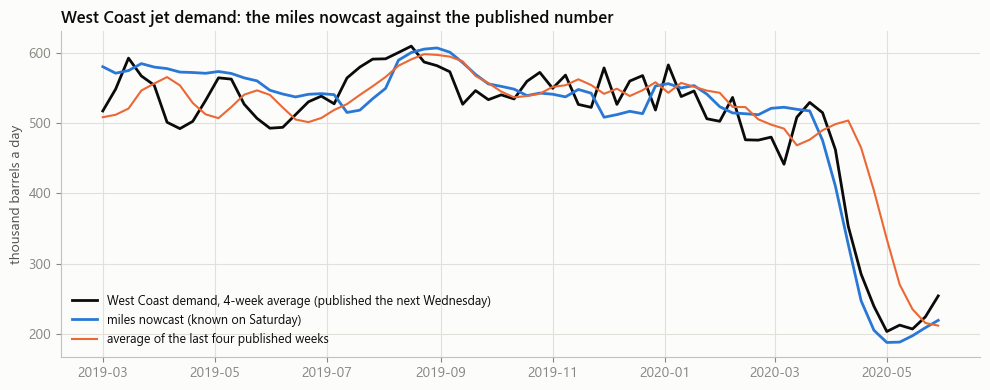

In [7]:
# Cell 15
fig, ax = plt.subplots(figsize=(10, 4))
W = A.loc[BEFORE[0]:COVID[1]]
ax.plot(W.index, W['P5_JET_DEMAND_4W'], color=INK, lw=2, label='West Coast demand, 4-week average (published the next Wednesday)')
ax.plot(W.index, W['NOWCAST_P5_JET_DEMAND_4W'], color=BLUE, lw=2, label='miles nowcast (known on Saturday)')
ax.plot(W.index, W['AVG4_P5_JET_DEMAND_4W'], color=ORANGE, lw=1.5, label='average of the last four published weeks')
ax.set_ylabel('thousand barrels a day')
ax.set_title('West Coast jet demand: the miles nowcast against the published number')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/nowcast_west_coast.png', dpi=150)
plt.show()

**Cell 16**

**Goal.** Show the nowcast, the published figure and the simple benchmark together.

**Method.** Plot West Coast 4-week demand, its nowcast and the 4-week average of published weeks, March 2019 to May 2020.

**Outcome.** The three lines run together through 2019 inside about 40 thousand barrels a day. In March 2020 the nowcast turns down first, the published line follows, and the average of published weeks turns last.

**Interpretation.** The value of the miles series is the turn ahead of the level: in calm weeks it adds 3 percent, and at a turning point it moves 1 to 2 weeks before an average of published weeks.

**Cell 17**

**Outcome.** PADD 5 weekly demand: nowcast error 93.1 against 95.9 kb/d for the best benchmark before the collapse, 3 percent lower, and 25 percent lower through the collapse. US weekly demand from combined miles: 4 percent lower before, 10 percent lower through. The 4-week demand target: 33 and 63 percent higher before, 26 and 34 percent lower through. The chart shows the nowcast turning down in March 2020 ahead of the 4-week benchmark.

**Interpretation.** Air-traffic data buys two things on this dataset: a 3 to 4 percent error reduction on the weekly figure, and an earlier turn. It costs accuracy on a smoothed target, where published history already holds the answer. The case for the feed rests on the turn, so the next section dates the turn against everything else that moved.

**Cell 18**

## 2. COVID sequence

Each series against its prior 8-week mean. Public: miles Saturday, EIA Wednesday, prices Friday.

In [8]:
# Cell 19
for col in ['P1_MILES', 'P5_MILES', 'US_JET_DEMAND', 'US_JET_DEMAND_4W']:
    A[col + '_VS_8W'] = 100 * (A[col] / A[col].shift(1).rolling(8).mean() - 1)
TIMELINE = A.loc['2020-02-07':'2020-05-01', ['P1_MILES_VS_8W', 'P5_MILES_VS_8W', 'US_JET_DEMAND_VS_8W', 'US_JET_DEMAND_4W_VS_8W', 'GC_JET_BRENT', 'HO_BRENT', 'LA_JET_M1M2']]
TIMELINE.round(1)

,P1_MILES_VS_8W,P5_MILES_VS_8W,US_JET_DEMAND_VS_8W,US_JET_DEMAND_4W_VS_8W,GC_JET_BRENT,HO_BRENT,LA_JET_M1M2
week_ending,,,,,,,
2020-02-07,-0.8,-4.8,-3.4,-6.2,22.2,32.3,0.6
2020-02-14,-0.8,-4.4,-17.4,-7.1,23.5,34.1,0.8
2020-02-21,-0.4,-2.6,-12.3,-9.0,18.2,29.9,0.9
2020-02-28,0.3,0.1,7.4,-6.6,13.8,25.9,-0.4
2020-03-06,1.7,2.9,-2.3,-6.4,17.9,30.3,-0.5
2020-03-13,2.8,4.9,9.8,0.5,19.7,35.9,-4.0
2020-03-20,2.6,5.4,-8.8,1.5,7.2,35.5,-4.7
2020-03-27,-9.0,-3.7,-15.4,-4.2,6.3,43.0,-1.4
2020-04-03,-24.0,-17.2,-50.9,-16.0,6.0,36.6,-20.5


**Cell 20**

**Goal.** Date the collapse in each series on one scale.

**Method.** State miles, weekly demand and 4-week demand as a percent of their own prior 8-week mean, then print February to May 2020 beside three price series.

**Outcome.** Through February and early March, miles stand inside 5 percent of their 8-week mean while US weekly demand swings from -17.4 to +9.8 percent. The Gulf Coast jet crack falls from 23.5 to 13.8 c/gal in the two weeks to 2020-02-28, and to 7.2 by 2020-03-20. Miles first break 20 percent below in the week to 2020-04-03, at -24.0 for the East Coast. LA jet M1-M2 falls from +0.9 to -4.7 by 2020-03-20 and to -20.5 by 2020-04-03.

**Interpretation.** The price series moved six weeks before the volume series. A trader watching miles saw the collapse in April; a trader watching the jet crack saw it in the week to 21 February. The -17.4 percent demand reading in mid-February, with miles flat, is a false alarm from the weekly stock survey, and surviving readings like it is the job of a nowcast.

In [9]:
# Cell 21
FIRST = []
for col, days_to_known, what in [('P1_MILES_VS_8W', 1, 'East Coast miles 20% below their 8-week average'),
                                 ('P5_MILES_VS_8W', 1, 'West Coast miles 20% below'),
                                 ('US_JET_DEMAND_VS_8W', 5, 'EIA weekly US jet demand 20% below'),
                                 ('US_JET_DEMAND_4W_VS_8W', 5, 'EIA 4-week US jet demand 20% below')]:
    week = A.index[(A[col] < -20) & (A.index >= '2020-02-01')].min()
    FIRST.append([what, week.date(), (week + pd.Timedelta(days=days_to_known)).date()])
crack_week = A.index[(A['GC_JET_BRENT'].diff() < -5) & (A.index >= '2020-02-01')].min()
FIRST.append(['Gulf Coast jet crack falls more than 5 c/gal in a week', crack_week.date(), crack_week.date()])
FIRST = pd.DataFrame(FIRST, columns=['signal', 'week ending', 'known on']).sort_values('known on')
FIRST

,signal,week ending,known on
4,Gulf Coast jet crack falls more than 5 c/gal i...,2020-02-21,2020-02-21
0,East Coast miles 20% below their 8-week average,2020-04-03,2020-04-04
2,EIA weekly US jet demand 20% below,2020-04-03,2020-04-08
1,West Coast miles 20% below,2020-04-10,2020-04-11
3,EIA 4-week US jet demand 20% below,2020-04-10,2020-04-15


**Cell 22**

**Goal.** Put one public date on each signal.

**Method.** For each volume series take the first week after 2020-02-01 crossing 20 percent below its 8-week mean, then add the publication lag: miles one day, EIA five days. For the price take the first week the Gulf Coast jet crack fell more than 5 c/gal, which is public the same day.

**Outcome.** Gulf Coast jet crack, public 2020-02-21. East Coast miles 2020-04-04. EIA weekly US demand 2020-04-08. West Coast miles 2020-04-11. EIA 4-week US demand 2020-04-15.

**Interpretation.** Six weeks separate the price signal from the first volume signal, and four days separate miles from the EIA weekly figure. Those four days are the edge the miles series carries. The six weeks say the market priced this collapse before any published volume number showed it, which bounds what an alternative-data feed is worth on an event of this size.

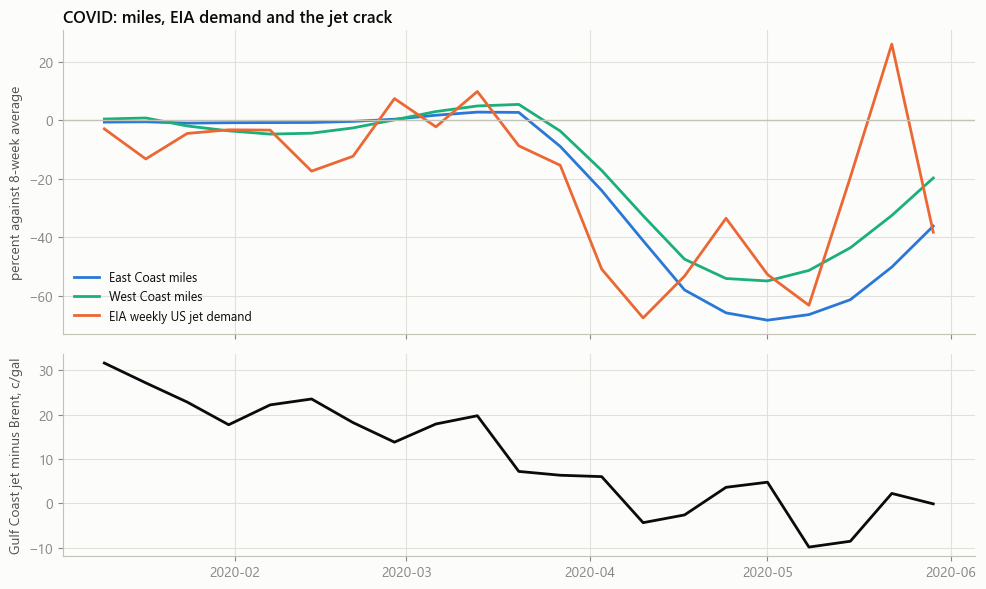

In [10]:
# Cell 23
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [3, 2]})
T = A.loc['2020-01-10':'2020-05-29']
axes[0].plot(T.index, T['P1_MILES_VS_8W'], color=BLUE, label='East Coast miles')
axes[0].plot(T.index, T['P5_MILES_VS_8W'], color=AQUA, label='West Coast miles')
axes[0].plot(T.index, T['US_JET_DEMAND_VS_8W'], color=ORANGE, label='EIA weekly US jet demand')
axes[0].axhline(0, color=AXIS, lw=1)
axes[0].set_ylabel('percent against 8-week average')
axes[0].set_title('COVID: miles, EIA demand and the jet crack')
axes[0].legend(loc='lower left', fontsize=9)
axes[1].plot(T.index, T['GC_JET_BRENT'], color=INK)
axes[1].set_ylabel('Gulf Coast jet minus Brent, c/gal')
plt.tight_layout()
plt.savefig('../figures/covid_timeline.png', dpi=150)
plt.show()

**Cell 24**

**Goal.** Show the order of the collapse in one picture.

**Method.** Two stacked panels: miles and demand against their 8-week means above, the Gulf Coast jet crack below, January to May 2020.

**Outcome.** The crack falls through February while the three volume lines sit near zero, and the volume lines fall in April.

**Interpretation.** The two panels are the finding of this section: the price fell first. A trade built on air-traffic data has to accept that in this episode the price carried the information earlier.

**Cell 25**

| Public | Signal |
|---|---|
| 2020-02-21 | GC jet crack: -5 c/gal in a week |
| 2020-04-04 | PADD 1 miles: -20 percent |
| 2020-04-08 | EIA weekly US demand: -20 percent, same week |
| 2020-04-11 | PADD 5 miles: -20 percent |
| 2020-04-15 | EIA 4-week US demand: -20 percent |

**Outcome.** Prices led the volume data by six weeks. Miles led the EIA weekly figure by four days and the 4-week figure by 11 days. In the week of 2020-02-14, EIA weekly demand read -17 percent and rebounded two weeks later while miles stayed inside 1 percent of their 8-week mean.

**Interpretation.** The four-day lead over the EIA is the operational value of the miles series, and it is small. The six-week lead the price held over every volume series is the larger fact: on this episode the market moved before the data. The February false alarm shows the other side, since a volume series that moves on survey noise costs a reader more than four days buys.

**Cell 26**

## 3. Miles against spreads

30 spreads × 8 miles features × 3 horizons = 720 regressions on 52 pre-COVID weeks. Control: gap to 26-week mean. Filter: Benjamini-Hochberg FDR, q = 0.10.

In [11]:
# Cell 27
SCORE = pd.read_csv(SCORE_FILE, index_col=0)
TARGETS = SCORE.index[(SCORE['group'] != 'flat') & (~SCORE['rebuilt'])].tolist()
MF = pd.DataFrame(index=A.index)
for miles, dem in [('P5_MILES', 'P5_JET_DEMAND_4W'), ('BOTH_MILES', 'US_JET_DEMAND_4W')]:
    MF[f'{miles}_SURPRISE'] = A[f'NOWCAST_{dem}'] - A[dem].shift(1)     # nowcast - last published demand
    MF[f'{miles}_CHG1'] = A[miles].pct_change()
    MF[f'{miles}_CHG4'] = A[miles].pct_change(4)
    MF[f'{miles}_VS_8W'] = A[miles] / A[miles].shift(1).rolling(8).mean() - 1
MILES_ROWS = []
for tgt in TARGETS:
    s = A[tgt]
    own_gap = s - PANEL[tgt].rolling(26).mean().reindex(A.index)
    for h in [1, 2, 4]:
        y = s.shift(-(1 + h)) - s.shift(-1)
        for f in MF.columns:
            df = pd.DataFrame({'y': y, 'x': MF[f], 'c': own_gap}).loc['2019-03-08':'2020-02-28'].dropna()
            if len(df) < 30:
                continue
            fit = sm.OLS(df['y'], sm.add_constant(df[['x', 'c']])).fit(cov_type='HAC', cov_kwds={'maxlags': h + 2})
            MILES_ROWS.append([tgt, f, h, len(df), fit.params['x'], fit.pvalues['x']])
MILES_SEARCH = pd.DataFrame(MILES_ROWS, columns=['spread', 'miles_feature', 'h', 'weeks', 'b', 'p'])
MM = len(MILES_SEARCH)
RANKED = np.sort(MILES_SEARCH['p'].values)
OK = RANKED <= FDR_Q * np.arange(1, MM + 1) / MM
print('combinations:', MM, '| p < 0.05:', int((MILES_SEARCH['p'] < 0.05).sum()), '| expected by chance:', round(0.05 * MM),
      '| pass the false discovery control:', int(OK.sum()) if OK.any() else 0)
MILES_SEARCH.sort_values('p').head(10).round(4)

combinations: 720 | p < 0.05: 59 | expected by chance: 36 | pass the false discovery control: 0


,spread,miles_feature,h,weeks,b,p
300,WTI_M1M2,BOTH_MILES_SURPRISE,2,52,-0.0011,0.0003
67,NWE_GC_1,P5_MILES_VS_8W,4,52,-20.5515,0.0004
692,HO_GASOIL,BOTH_MILES_SURPRISE,4,52,0.0151,0.0006
292,WTI_M1M2,BOTH_MILES_SURPRISE,1,52,-0.0007,0.0010
32,NY_GC_1,P5_MILES_SURPRISE,2,52,0.0109,0.0019
209,NY_JET_M1M2,P5_MILES_CHG1,4,52,-12.9979,0.0025
671,BRENT_WTI,BOTH_MILES_VS_8W,4,52,-33.6176,0.0043
143,LA_JET_M2M3,BOTH_MILES_VS_8W,4,52,29.1647,0.0046
670,BRENT_WTI,BOTH_MILES_CHG4,4,52,-29.1982,0.0047
316,WTI_M2M3,BOTH_MILES_SURPRISE,1,52,-0.0008,0.0065


**Cell 28**

**Goal.** Test whether a miles feature predicts a spread beyond the spread's own reversion.

**Method.** Eight miles features against 30 spreads at three horizons, on 52 weeks before the collapse. The features: the nowcast surprise against last published demand, the 1-week and 4-week percent change, and the level against the 8-week mean, for each of the two regions. Each regression controls for the spread's gap to its 26-week mean and uses Newey-West standard errors. Then apply the Benjamini-Hochberg cutoff at q = 0.10.

**Outcome.** 720 combinations. 59 at p < 0.05 against 36 expected by chance. Zero pass the false-discovery cutoff. Smallest p-values: WTI M1-M2 with the US nowcast surprise 0.0003, NWE_GC_1 with West Coast miles against their 8-week mean 0.0004, HO_GASOIL with the US nowcast surprise 0.0006.

**Interpretation.** 59 against 36 leaves about 23 combinations carrying signal, spread across 720, and the correction for having tried 720 rejects every one. The smallest p-value pairs a crude oil time spread with a jet-traffic feature, a pairing that lacks a physical mechanism, which is what a false positive looks like. The binding limit is 52 weeks of data: the same test needs OpenSky history from 2017 to carry weight.

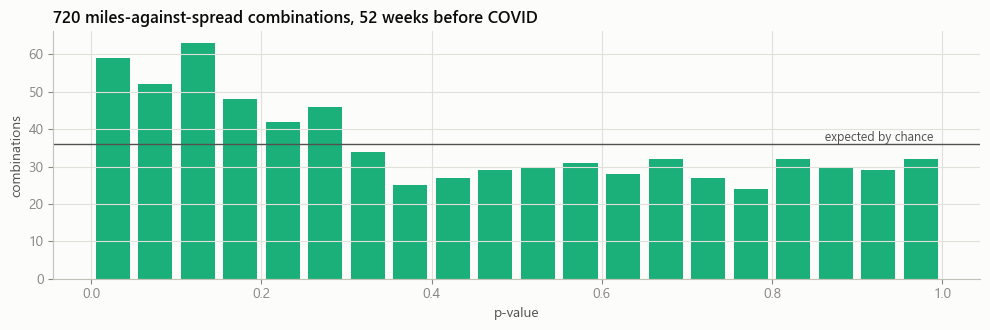

In [12]:
# Cell 29
fig, ax = plt.subplots(figsize=(10, 3.4))
counts, edges = np.histogram(MILES_SEARCH['p'], bins=20, range=(0, 1))
ax.bar(edges[:-1] + 0.025, counts, width=0.04, color=AQUA)
ax.axhline(MM / 20, color=INK_2, lw=1)
ax.text(0.99, MM / 20, '  expected by chance', va='bottom', ha='right', color=INK_2, fontsize=9)
ax.set_xlabel('p-value')
ax.set_ylabel('combinations')
ax.set_title('720 miles-against-spread combinations, 52 weeks before COVID')
plt.tight_layout()
plt.savefig('../figures/miles_search_pvalues.png', dpi=150)
plt.show()

**Cell 30**

**Goal.** Compare the 720 p-values against chance.

**Method.** Histogram the p-values in 20 bins with a line at 36 per bin.

**Outcome.** The lowest bin stands above the line and the rest sit at or near it.

**Interpretation.** One raised bin out of 20, on 720 tests over 52 weeks, is what chance produces. The picture closes the price question on this dataset and leaves the demand nowcast as the result this notebook keeps.

**Cell 31**

**Outcome.** 59 of 720 combinations reached p < 0.05 against 36 expected by chance, and zero passed the false discovery cutoff. A price test at weight needs OpenSky history from 2017, which sits in the research database. The usable result is regional demand, four days ahead of the EIA.

**Interpretation.** On 52 weeks this dataset answers the price question with a flat result, and 52 weeks lacks the power to settle it either way. The nowcast stands as the deliverable from air-traffic data, and the price question stays open against a longer history.

In [13]:
# Cell 32
NOWCAST_SCORES.to_csv('../results/nowcast_scores.csv', index=False)
MILES_SEARCH.to_csv('../results/miles_search.csv', index=False)
FIRST.to_csv('../results/covid_first_signals.csv', index=False)
print('saved')

saved


**Cell 33**

**Goal.** Save the three result tables.

**Method.** Write `nowcast_scores.csv`, `miles_search.csv` and `covid_first_signals.csv` to `results/`.

**Outcome.** Three files saved.

**Interpretation.** These three tables hold the air-traffic numbers the README and the dashboard cite.

**Cell 34**

## Summary

| Test | Result |
|---|---|
| Nowcast, weekly demand | error 3 to 4 percent lower before the collapse; 10 to 25 percent lower through it |
| Nowcast, 4-week demand | error 33 to 63 percent higher before the collapse; 26 to 34 percent lower through it |
| COVID sequence | prices 2020-02-21; PADD 1 miles 2020-04-04; EIA 2020-04-08 |
| Miles against spreads | 0 of 720 pass FDR on 52 weeks |
| Next | OpenSky history from 2017 |

**Outcome.** Flight miles nowcast the EIA weekly jet demand figure four days early with 3 to 4 percent less error in calm weeks and 10 to 25 percent less through the collapse, and they leave all 30 spreads unpredicted on 52 weeks.

**Interpretation.** Air-traffic data is a demand instrument here in place of a price signal. It reports the physical quantity sooner than the official source, which feeds the fair values in notebook 03 through their demand columns, and its edge on the spreads themselves stays below what 52 weeks can measure. Extending the miles history to 2017 is the one test that would change that reading.